In [13]:
import os
import time
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt

In [2]:
# Fijar semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

# Asegurar la creación física del directorio base para evitar errores de ruta en Windows
os.makedirs("tuner_dir", exist_ok=True)

In [3]:
# ==========================================
# 1. DESCARGA Y PREPROCESAMIENTO DE DATOS
# ==========================================
print("Descargando datos de Alphabet Inc. (GOOGL)...")
df = yf.download('GOOGL', start='2017-01-01', end='2024-01-01')
data = df[['Close']].values

# División Train (80%) / Test (20%)
train_size = int(len(data) * 0.8)
train_data_raw = data[:train_size]
test_data_raw = data[train_size:]

# Escalador
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data_raw)
test_scaled = scaler.transform(test_data_raw)

# Función para crear ventanas temporales
def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:(i + time_step), 0])
        y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(y)

TIME_STEP = 60

X_train, y_train = create_dataset(train_scaled, TIME_STEP)
test_combined = np.concatenate((train_scaled[-TIME_STEP:], test_scaled), axis=0)
X_test, y_test = create_dataset(test_combined, TIME_STEP)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
]

Descargando datos de Alphabet Inc. (GOOGL)...


[*********************100%***********************]  1 of 1 completed


In [4]:
# ==========================================
# 2. MODELADO Y ENTRENAMIENTO (LSTM)
# ==========================================
def build_lstm_model(hp):
    model = Sequential([
        Input(shape=(TIME_STEP, 1)),
        LSTM(units=hp.Int('units_1', 32, 128, step=32), return_sequences=True),
        Dropout(hp.Float('dropout_1', 0.1, 0.4, step=0.1)),
        LSTM(units=hp.Int('units_2', 32, 128, step=32), return_sequences=False),
        Dropout(hp.Float('dropout_2', 0.1, 0.4, step=0.1)),
        Dense(units=hp.Int('dense_units', 16, 64, step=16), activation='relu'),
        Dense(1)
    ])
    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 5e-4])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='mean_squared_error')
    return model

print("\n--- Optimizando hiperparámetros de LSTM ---")
tuner_lstm = kt.RandomSearch(
    build_lstm_model, objective='val_loss', max_trials=8,
    directory='tuner_dir', project_name='lstm_googl', overwrite=True
)
tuner_lstm.search(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), callbacks=callbacks, verbose=1)

best_lstm_hps = tuner_lstm.get_best_hyperparameters(num_trials=1)[0]
best_lstm_model = tuner_lstm.hypermodel.build(best_lstm_hps)

start_time_lstm = time.time()
history_lstm = best_lstm_model.fit(
    X_train, y_train, epochs=50, batch_size=32,
    validation_data=(X_test, y_test), callbacks=callbacks, verbose=1
)
time_lstm = time.time() - start_time_lstm

Trial 8 Complete [00h 02m 39s]
val_loss: 0.001580584910698235

Best val_loss So Far: 0.0009304992272518575
Total elapsed time: 00h 19m 33s
Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - loss: 0.0389 - val_loss: 0.0025 - learning_rate: 0.0100
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 0.0034 - val_loss: 0.0017 - learning_rate: 0.0100
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 0.0024 - val_loss: 0.0019 - learning_rate: 0.0100
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.0023 - val_loss: 0.0016 - learning_rate: 0.0100
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0018 - val_loss: 0.0018 - learning_rate: 0.0100
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 0.0019 - val_loss: 0.0028 - learning_rate: 0.0100
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 0.0024 - val_loss: 0.0040 - learning_rate: 0.0100
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0022 - val_loss: 0.0015 - learning_r

In [5]:
# ==========================================
# 3. MODELADO Y ENTRENAMIENTO (GRU)
# ==========================================
def build_gru_model(hp):
    model = Sequential([
        Input(shape=(TIME_STEP, 1)),
        GRU(units=hp.Int('units_1', 32, 128, step=32), return_sequences=True),
        Dropout(hp.Float('dropout_1', 0.1, 0.4, step=0.1)),
        GRU(units=hp.Int('units_2', 32, 128, step=32), return_sequences=False),
        Dropout(hp.Float('dropout_2', 0.1, 0.4, step=0.1)),
        Dense(units=hp.Int('dense_units', 16, 64, step=16), activation='relu'),
        Dense(1)
    ])
    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 5e-4])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='mean_squared_error')
    return model

print("\n--- Optimizando hiperparámetros de GRU ---")
tuner_gru = kt.RandomSearch(
    build_gru_model, objective='val_loss', max_trials=8,
    directory='tuner_dir', project_name='gru_googl', overwrite=True
)
tuner_gru.search(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), callbacks=callbacks, verbose=1)

best_gru_hps = tuner_gru.get_best_hyperparameters(num_trials=1)[0]
best_gru_model = tuner_gru.hypermodel.build(best_gru_hps)

start_time_gru = time.time()
history_gru = best_gru_model.fit(
    X_train, y_train, epochs=50, batch_size=32,
    validation_data=(X_test, y_test), callbacks=callbacks, verbose=1
)
time_gru = time.time() - start_time_gru

Trial 8 Complete [00h 03m 05s]
val_loss: 0.0005392287857830524

Best val_loss So Far: 0.0005189627991057932
Total elapsed time: 00h 23m 33s
Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step - loss: 0.0197 - val_loss: 0.0021 - learning_rate: 0.0100
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - loss: 0.0022 - val_loss: 0.0015 - learning_rate: 0.0100
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - loss: 0.0015 - val_loss: 0.0018 - learning_rate: 0.0100
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - loss: 0.0014 - val_loss: 0.0045 - learning_rate: 0.0100
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step - loss: 0.0017 - val_loss: 0.0084 - learning_rate: 0.0100
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - loss: 0.0020 - val_loss: 5.8688e-04 - learning_rate: 0.0050
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - loss: 0.0011 - val_loss: 6.1788e-04 - learning_rate: 0.0050
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 138ms/step - loss: 0.0014 - val_loss: 5.3

In [6]:
# ==========================================
# 4. PREDICCIONES Y MÉTRICAS
# ==========================================
pred_lstm_scaled = best_lstm_model.predict(X_test)
pred_gru_scaled = best_gru_model.predict(X_test)

pred_lstm = scaler.inverse_transform(pred_lstm_scaled)
pred_gru = scaler.inverse_transform(pred_gru_scaled)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

mae_naive_train = np.mean(np.abs(np.diff(train_data_raw[:, 0])))

def calculate_smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return np.mean(np.abs(y_pred - y_true) / denominator) * 100

def calculate_mase(y_true, y_pred, mae_naive):
    return mean_absolute_error(y_true, y_pred) / mae_naive

def evaluate_model(y_true, y_pred, name, model, train_time):
    return {
        "Modelo": name, 
        "RMSE ($)": np.sqrt(mean_squared_error(y_true, y_pred)), 
        "MAE ($)": mean_absolute_error(y_true, y_pred), 
        "MAPE (%)": mean_absolute_percentage_error(y_true, y_pred) * 100,
        "sMAPE (%)": calculate_smape(y_true, y_pred),
        "MASE": calculate_mase(y_true, y_pred, mae_naive_train),
        "Tiempo Entr. (s)": round(train_time, 2),
        "Parámetros Totales": model.count_params()
    }

df_metrics = pd.DataFrame([
    evaluate_model(y_test_real, pred_lstm, "LSTM Único", best_lstm_model, time_lstm),
    evaluate_model(y_test_real, pred_gru, "GRU Único", best_gru_model, time_gru)
])

print("\n" + "="*105)
print("TABLA COMPARATIVA DE RENDIMIENTO Y COSTE COMPUTACIONAL (GOOGL)")
print("="*105)
print(df_metrics.to_string(index=False))
print("="*105)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step

TABLA COMPARATIVA DE RENDIMIENTO Y COSTE COMPUTACIONAL (GOOGL)
    Modelo  RMSE ($)  MAE ($)  MAPE (%)  sMAPE (%)     MASE  Tiempo Entr. (s)  Parámetros Totales
LSTM Único  3.379581 2.625146  2.402294   2.394418 2.654981            238.08               30241
 GRU Único  2.513300 1.889189  1.735952   1.733586 1.910660            106.92               61089


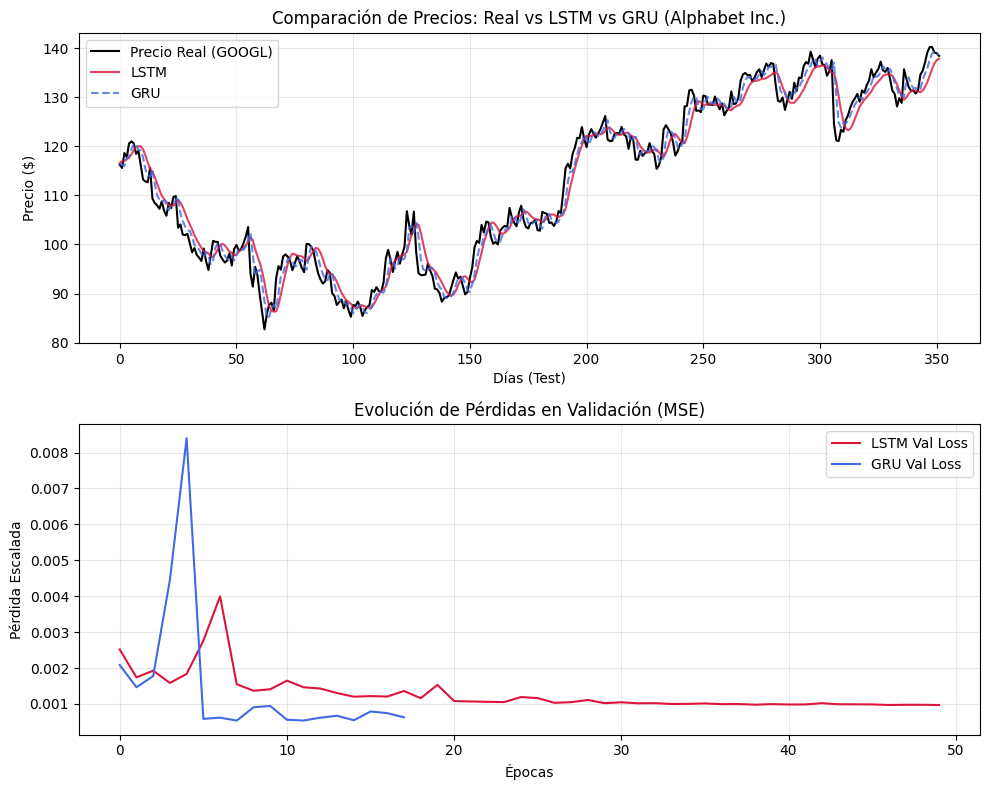

In [7]:
# ==========================================
# 5. VISUALIZACIONES
# ==========================================

# ------------------------------------------
# FIGURA 1: CUADRÍCULA 2x1 (PRECIOS COMPARADOS + VAL LOSS)
# ------------------------------------------
fig1, axs1 = plt.subplots(2, 1, figsize=(10, 8))

axs1[0].plot(y_test_real, color='black', label='Precio Real (GOOGL)', linewidth=1.5)
axs1[0].plot(pred_lstm, color='crimson', label='LSTM', alpha=0.8)
axs1[0].plot(pred_gru, color='royalblue', linestyle='--', label='GRU', alpha=0.8)
axs1[0].set_title('Comparación de Precios: Real vs LSTM vs GRU (Alphabet Inc.)')
axs1[0].set_xlabel('Días (Test)')
axs1[0].set_ylabel('Precio ($)')
axs1[0].legend()
axs1[0].grid(True, alpha=0.3)

axs1[1].plot(history_lstm.history['val_loss'], color='crimson', label='LSTM Val Loss')
axs1[1].plot(history_gru.history['val_loss'], color='royalblue', label='GRU Val Loss')
axs1[1].set_title('Evolución de Pérdidas en Validación (MSE)')
axs1[1].set_xlabel('Épocas')
axs1[1].set_ylabel('Pérdida Escalada')
axs1[1].legend()
axs1[1].grid(True, alpha=0.3)

plt.tight_layout()

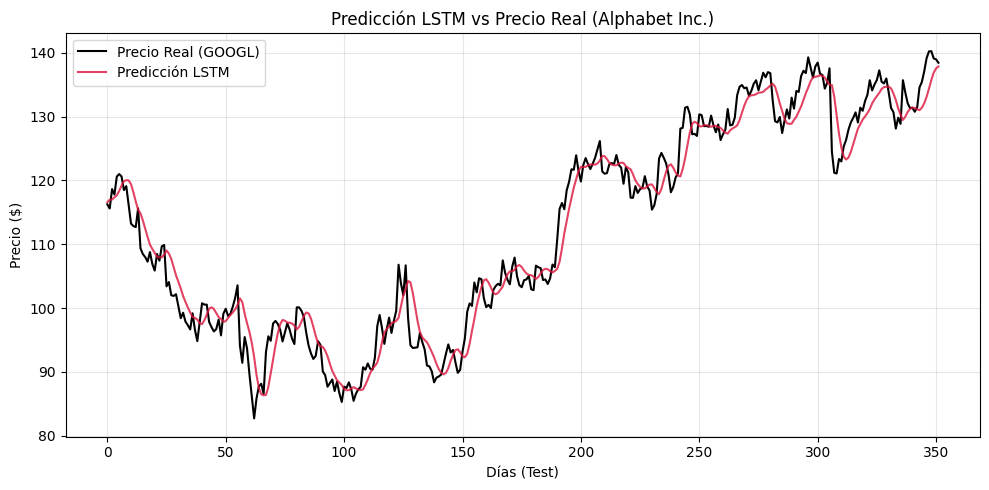

In [8]:
# ------------------------------------------
# FIGURA 2: INDEPENDIENTE - LSTM vs PRECIO REAL
# ------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(y_test_real, color='black', label='Precio Real (GOOGL)', linewidth=1.5)
plt.plot(pred_lstm, color='crimson', label='Predicción LSTM', alpha=0.8)
plt.title('Predicción LSTM vs Precio Real (Alphabet Inc.)')
plt.xlabel('Días (Test)')
plt.ylabel('Precio ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

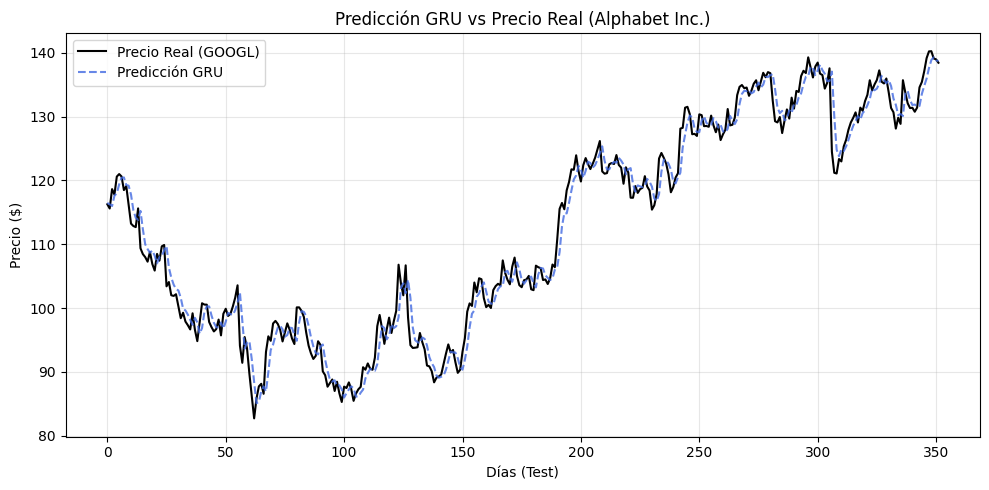

In [9]:
# ------------------------------------------
# FIGURA 3: INDEPENDIENTE - GRU vs PRECIO REAL
# ------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(y_test_real, color='black', label='Precio Real (GOOGL)', linewidth=1.5)
plt.plot(pred_gru, color='royalblue', linestyle='--', label='Predicción GRU', alpha=0.8)
plt.title('Predicción GRU vs Precio Real (Alphabet Inc.)')
plt.xlabel('Días (Test)')
plt.ylabel('Precio ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

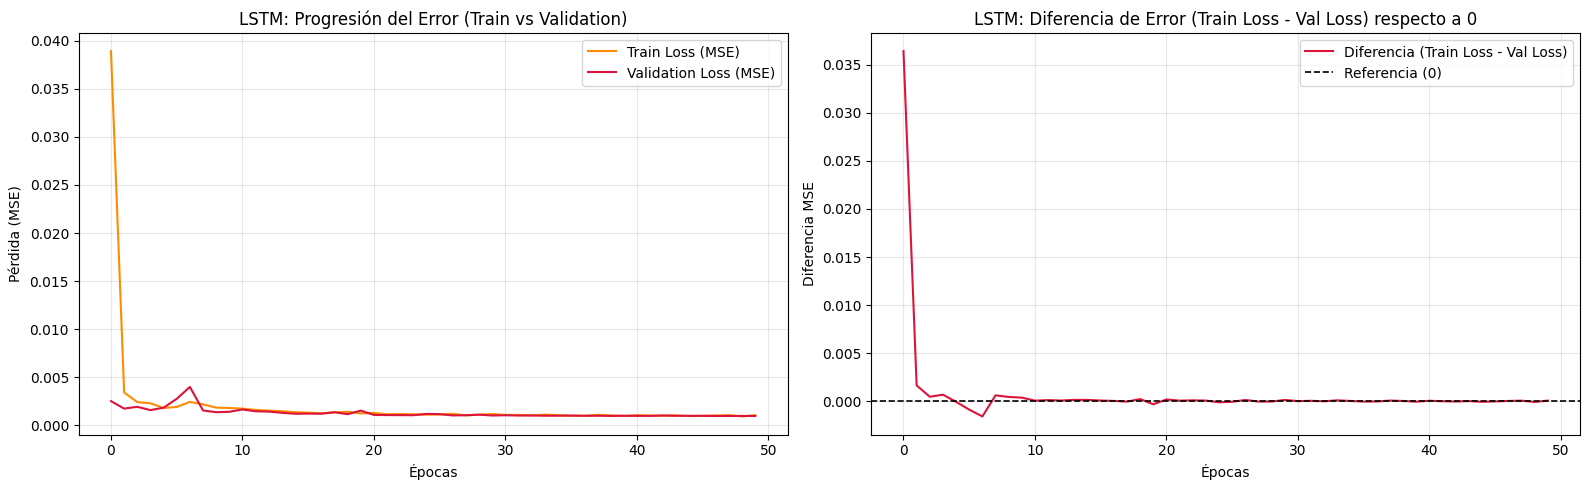

In [10]:
# ------------------------------------------
# FIGURA 4: DIAGNÓSTICO DE ERROR EN LSTM (Cuadrícula 1x2)
# ------------------------------------------
fig4, axs4 = plt.subplots(1, 2, figsize=(16, 5))

lstm_train_loss = np.array(history_lstm.history['loss'])
lstm_val_loss = np.array(history_lstm.history['val_loss'])
lstm_diff = lstm_train_loss - lstm_val_loss

axs4[0].plot(lstm_train_loss, color='darkorange', label='Train Loss (MSE)')
axs4[0].plot(lstm_val_loss, color='crimson', label='Validation Loss (MSE)')
axs4[0].set_title('LSTM: Progresión del Error (Train vs Validation)')
axs4[0].set_xlabel('Épocas')
axs4[0].set_ylabel('Pérdida (MSE)')
axs4[0].legend()
axs4[0].grid(True, alpha=0.3)

axs4[1].plot(lstm_diff, color='crimson', label='Diferencia (Train Loss - Val Loss)')
axs4[1].axhline(0, color='black', linestyle='--', linewidth=1.2, label='Referencia (0)')
axs4[1].set_title('LSTM: Diferencia de Error (Train Loss - Val Loss) respecto a 0')
axs4[1].set_xlabel('Épocas')
axs4[1].set_ylabel('Diferencia MSE')
axs4[1].legend()
axs4[1].grid(True, alpha=0.3)

plt.tight_layout()

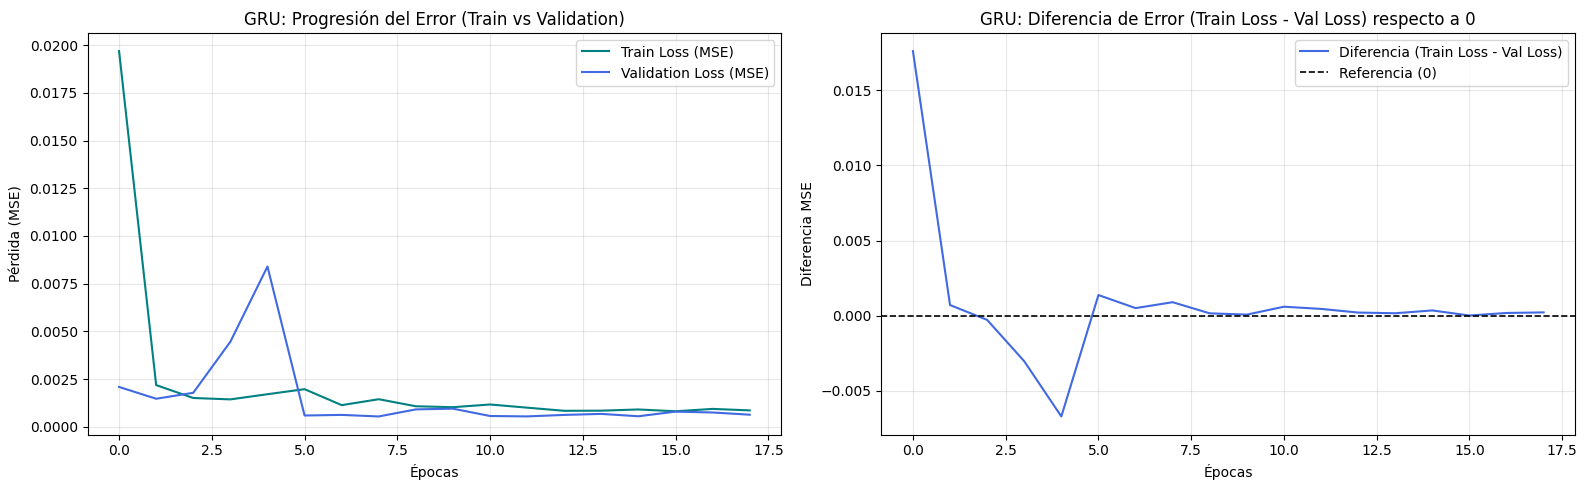

In [11]:
# ------------------------------------------
# FIGURA 5: DIAGNÓSTICO DE ERROR EN GRU (Cuadrícula 1x2)
# ------------------------------------------
fig5, axs5 = plt.subplots(1, 2, figsize=(16, 5))

gru_train_loss = np.array(history_gru.history['loss'])
gru_val_loss = np.array(history_gru.history['val_loss'])
gru_diff = gru_train_loss - gru_val_loss

axs5[0].plot(gru_train_loss, color='teal', label='Train Loss (MSE)')
axs5[0].plot(gru_val_loss, color='royalblue', label='Validation Loss (MSE)')
axs5[0].set_title('GRU: Progresión del Error (Train vs Validation)')
axs5[0].set_xlabel('Épocas')
axs5[0].set_ylabel('Pérdida (MSE)')
axs5[0].legend()
axs5[0].grid(True, alpha=0.3)

axs5[1].plot(gru_diff, color='royalblue', label='Diferencia (Train Loss - Val Loss)')
axs5[1].axhline(0, color='black', linestyle='--', linewidth=1.2, label='Referencia (0)')
axs5[1].set_title('GRU: Diferencia de Error (Train Loss - Val Loss) respecto a 0')
axs5[1].set_xlabel('Épocas')
axs5[1].set_ylabel('Diferencia MSE')
axs5[1].legend()
axs5[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# ==========================================
# 6. EXTRACCIÓN DE HIPERPARÁMETROS SELECCIONADOS
# ==========================================
def obtener_mejores_hps(project_name):
    # Buscar todos los archivos de estado de los trials en la carpeta del proyecto
    json_pattern = f"tuner_dir/{project_name}/trial_*/trial.json"
    files = glob.glob(json_pattern)
    
    if not files:
        return {"Modelo": project_name, "Estado": "No se encontraron archivos en tuner_dir"}

    best_score = float('inf')
    best_hps = None

    # Recorrer los resultados guardados en disco para encontrar el de menor val_loss
    for file_path in files:
        with open(file_path, 'r') as f:
            data = json.load(f)
            # Verificar si el trial finalizó con éxito y tiene métricas
            if data.get('status') == 'COMPLETED' and 'val_loss' in data.get('metrics', {}).get('metrics', {}):
                val_loss = data['metrics']['metrics']['val_loss']['observations'][0]['value'][0]
                if val_loss < best_score:
                    best_score = val_loss
                    best_hps = data['hyperparameters']['values']

    if best_hps is None:
        return {"Modelo": project_name, "Estado": "Sin datos de validación"}

    return {
        "Modelo": project_name,
        "Unidades Capa 1": best_hps.get('units_1'),
        "Dropout Capa 1": best_hps.get('dropout_1'),
        "Unidades Capa 2": best_hps.get('units_2'),
        "Dropout Capa 2": best_hps.get('dropout_2'),
        "Unidades Dense": best_hps.get('dense_units'),
        "Learning Rate": best_hps.get('learning_rate'),
        "Mejor Val Loss": round(best_score, 6)
    }

# Extraer parámetros de los directorios de LSTM y GRU guardados
datos_lstm = obtener_mejores_hps("lstm_googl")
datos_gru = obtener_mejores_hps("gru_googl")

# Mostrar resultados en tabla
df_hps = pd.DataFrame([datos_lstm, datos_gru])

print("\n" + "="*85)
print("HIPERPARÁMETROS RECUPERADOS DIRECTAMENTE DEL HISTORIAL (JSON)")
print("="*85)
print(df_hps.to_string(index=False))
print("="*85)


HIPERPARÁMETROS RECUPERADOS DIRECTAMENTE DEL HISTORIAL (JSON)
    Modelo  Unidades Capa 1  Dropout Capa 1  Unidades Capa 2  Dropout Capa 2  Unidades Dense  Learning Rate  Mejor Val Loss
lstm_googl               32             0.2               64             0.3              16           0.01        0.000930
 gru_googl               64             0.1               96             0.3              16           0.01        0.000519
